# Post-2050 predicted TREFMXAV_U analysis  

This notebook analyses the post-2050 predictions generated by the final XGBoost model.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent

else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/jacobwoodland/Semester 2/EART60702/Assignment 2/Project Folder/eds_project2


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from src.config import TABLES_DIR, FIGURES_DIR

In [3]:
post2050 = pd.read_csv(TABLES_DIR / "post2050_predictions.csv")

# Convert longitudes to typical format as opposed to 0 - 360 system

post2050_plot = post2050.copy()
post2050_plot["lon_plot"] = ((post2050_plot["lon"] + 180) % 360) - 180

In [4]:
print(post2050_plot.columns.tolist())
print(post2050_plot.shape)
post2050_plot.head()

['scenario', 'time', 'TREFMXAV_U', 'TREFHT', 'FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'UBOT', 'VBOT', 'lat', 'lon', 'year', 'month', 'monthly_sin', 'monthly_cos', 'wind_speed', 'TREFHT_lag1', 'PRECT_lag1', 'PRSN_lag1', 'FLNS_lag1', 'FSNS_lag1', 'QBOT_lag1', 'wind_speed_lag1', 'pred_TREFMXAV_U', 'lon_plot']
(93744, 27)


,scenario,time,TREFMXAV_U,TREFHT,FLNS,FSNS,PRECT,PRSN,QBOT,UBOT,...,wind_speed,TREFHT_lag1,PRECT_lag1,PRSN_lag1,FLNS_lag1,FSNS_lag1,QBOT_lag1,wind_speed_lag1,pred_TREFMXAV_U,lon_plot
0,3,2050-01-01 00:00:00,285.80136,283.99677,37.516384,30.577051,2.521736e-06,1.648166e-14,0.006410,5.582342,...,7.836511,282.48373,4.135034e-07,2.540881e-14,58.289960,34.724420,0.005628,2.141264,285.69520,-1.25
1,3,2050-02-01 00:00:00,285.41544,282.44060,66.326950,79.958450,8.721353e-07,3.524978e-14,0.005101,-0.701649,...,2.899583,283.99677,2.521736e-06,1.648166e-14,37.516384,30.577051,0.006410,7.836511,285.14316,-1.25
2,3,2050-03-01 00:00:00,284.60860,281.54675,60.539158,117.381300,7.776718e-07,7.428997e-10,0.004784,-1.219418,...,1.402428,282.44060,8.721353e-07,3.524978e-14,66.326950,79.958450,0.005101,2.899583,284.75696,-1.25
3,3,2050-04-01 00:00:00,289.54980,284.74783,59.838787,176.792770,9.672199e-07,2.614217e-14,0.005760,1.609725,...,1.632368,281.54675,7.776718e-07,7.428997e-10,60.539158,117.381300,0.004784,1.402428,289.38780,-1.25
4,3,2050-05-01 00:00:00,294.81363,288.92102,66.239780,248.411360,2.893328e-07,2.476724e-15,0.007576,-2.432174,...,3.282235,284.74783,9.672199e-07,2.614217e-14,59.838787,176.792770,0.005760,1.632368,294.00480,-1.25


## Annual prediction trajectories by scenario

Aggregate predictions to annual means for each scenario

In [5]:
annual_preds = (
    post2050_plot
    .groupby(["scenario", "year"])["pred_TREFMXAV_U"]
    .mean()
    .reset_index()
)

annual_preds.head()

,scenario,year,pred_TREFMXAV_U
0,3,2050,288.701367
1,3,2051,288.900843
2,3,2052,288.868417
3,3,2053,288.693304
4,3,2054,288.705980


In [6]:
# Check all scenarios and full period are there

annual_preds.groupby("scenario")["year"].agg(["min", "max", "count"])

,min,max,count
scenario,,,
3,2050,2080,31
4,2050,2080,31
5,2050,2080,31
6,2050,2080,31
7,2050,2080,31
8,2050,2080,31


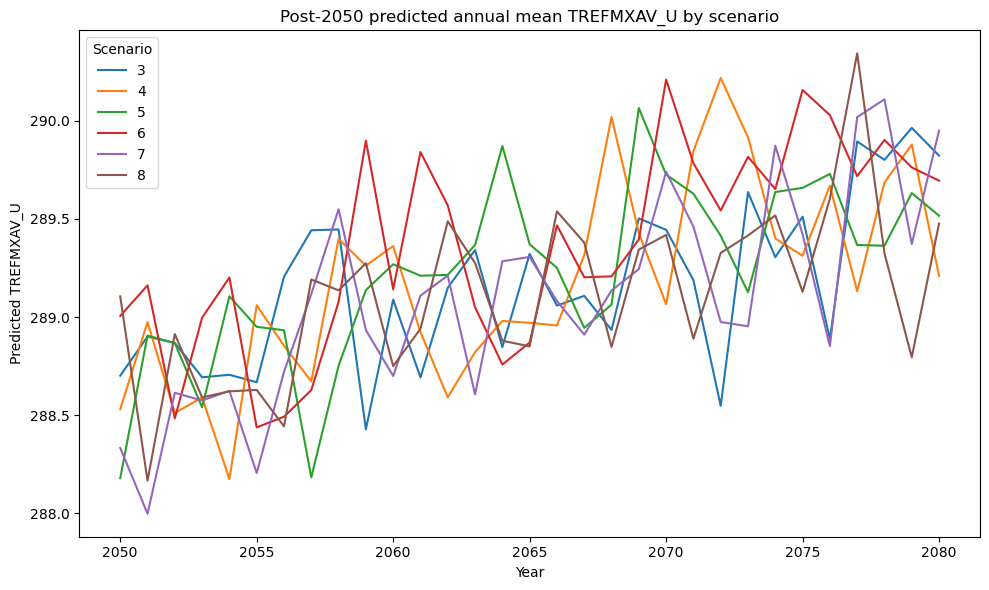

In [7]:
plt.figure(figsize=(10, 6))

for scenario, grp in annual_preds.groupby("scenario"):
    plt.plot(grp["year"], grp["pred_TREFMXAV_U"], label=scenario)

plt.title("Post-2050 predicted annual mean TREFMXAV_U by scenario")
plt.xlabel("Year")
plt.ylabel("Predicted TREFMXAV_U")
plt.legend(title="Scenario")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_annual_trajectories_by_scenario_raw.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
annual_summary = (
    annual_preds
    .groupby("scenario")["pred_TREFMXAV_U"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

annual_summary

,scenario,mean,min,max
0,3,289.164900,288.428441,289.963739
1,4,289.184918,288.175240,290.217960
2,5,289.225299,288.179486,290.064985
3,6,289.359944,288.438131,290.210075
4,7,289.096407,287.998383,290.109453
5,8,289.116446,288.167002,290.343588


In [9]:
annual_summary.to_csv(TABLES_DIR / "post2050_annual_summary_by_scenario.csv", index=False)

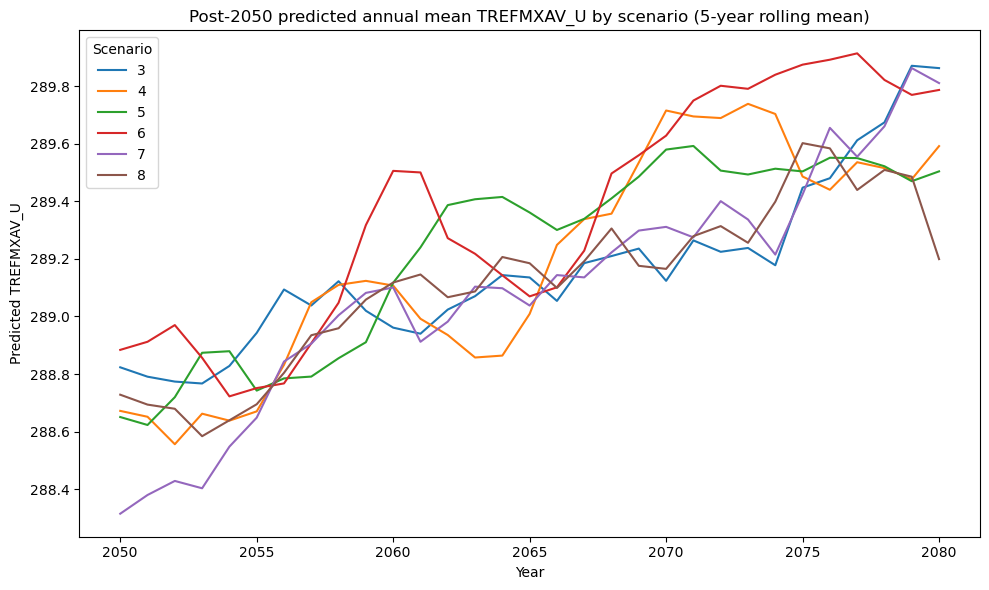

In [10]:
# Improve the plot by smoothing some of the noise using a 5-year rolling avergae

annual_preds = annual_preds.sort_values(["scenario", "year"]).copy()

annual_preds["pred_smooth_5yr"] = (
    annual_preds
    .groupby("scenario")["pred_TREFMXAV_U"]
    .transform(lambda s: s.rolling(window=5, center=True, min_periods=1).mean())
)

plt.figure(figsize=(10, 6))

for scenario, grp in annual_preds.groupby("scenario"):
    plt.plot(grp["year"], grp["pred_smooth_5yr"], label=scenario)

plt.title("Post-2050 predicted annual mean TREFMXAV_U by scenario (5-year rolling mean)")
plt.xlabel("Year")
plt.ylabel("Predicted TREFMXAV_U")
plt.legend(title="Scenario")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_annual_trajectories_by_scenario_5yr_rolling_mean.png", dpi=300, bbox_inches="tight")
plt.show()

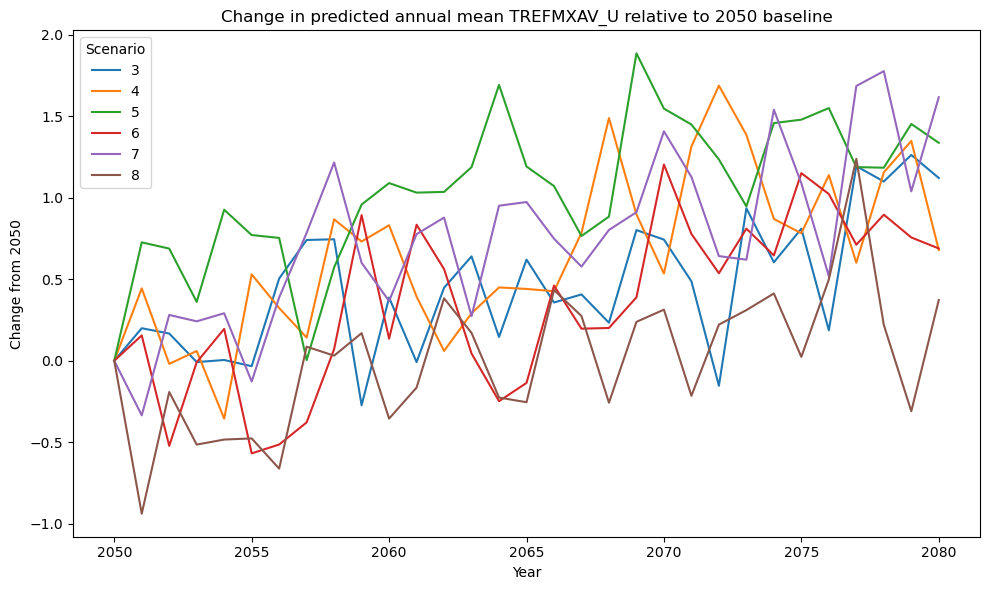

In [11]:
# PLot relative to 2050 baseline year

annual_change = annual_preds.copy()

baseline = (
    annual_change[annual_change["year"]==2050]
    .set_index("scenario")["pred_TREFMXAV_U"]
)

annual_change["baseline_2050"] = annual_change["scenario"].map(baseline)
annual_change["change_from_2050"] = annual_change["pred_TREFMXAV_U"] - annual_change["baseline_2050"]

plt.figure(figsize=(10, 6))

for scenario, grp in annual_change.groupby("scenario"):
    plt.plot(grp["year"], grp["change_from_2050"], label=scenario)

plt.title("Change in predicted annual mean TREFMXAV_U relative to 2050 baseline")
plt.xlabel("Year")
plt.ylabel("Change from 2050")
plt.legend(title="Scenario")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_annual_change_relative_to_2050_by_scenario.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# Summarise over decades

def assign_period(year):
    if 2050 <= year <= 2059:
        return "2050s"
    elif 2060 <= year <= 2069:
        return "2060s"
    else:
        return "2070s"
    
annual_preds["period"] = annual_preds["year"].apply(assign_period)

period_summary = (
    annual_preds
    .groupby(["scenario", "period"])["pred_TREFMXAV_U"]
    .mean()
    .reset_index()
)

period_summary

,scenario,period,pred_TREFMXAV_U
0,3,2050s,288.906087
1,3,2060s,289.104639
2,3,2070s,289.454968
3,4,2050s,288.802996
4,4,2060s,289.136921
5,4,2070s,289.575755
6,5,2050s,288.755590
7,5,2060s,289.362906
8,5,2070s,289.527209
9,6,2050s,288.938622


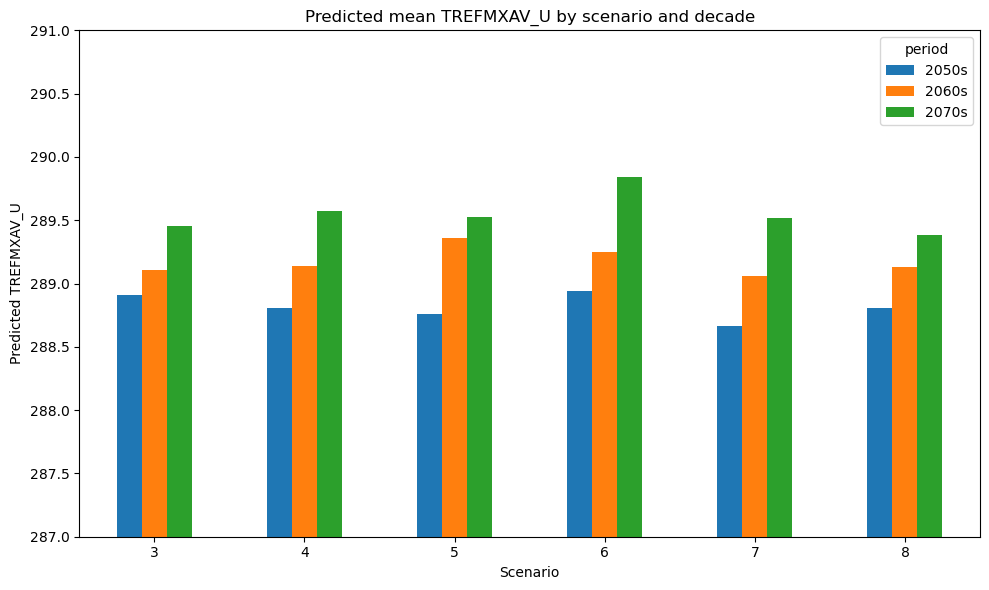

In [13]:
period_pivot = period_summary.pivot(index="scenario", columns="period", values="pred_TREFMXAV_U")

ax = period_pivot.plot(kind="bar", figsize=(10, 6))
ax.set_title("Predicted mean TREFMXAV_U by scenario and decade")
ax.set_xlabel("Scenario")
ax.set_ylabel("Predicted TREFMXAV_U")
ax.set_ylim(287,291)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mean_predicted_TREFMXAV_U_by_scenario_and_decade.png", dpi=300, bbox_inches="tight")
plt.show()

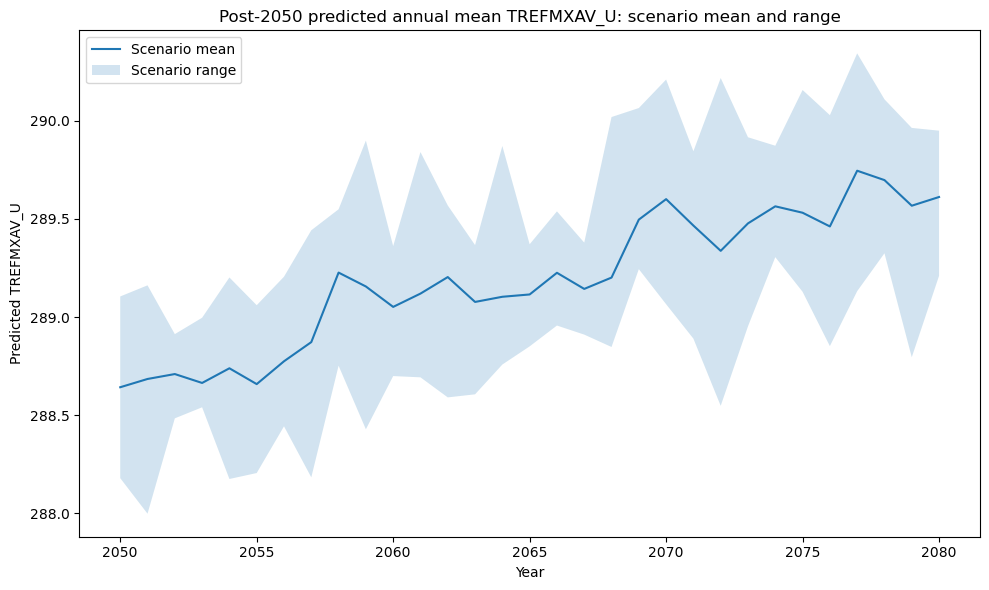

In [14]:
# Overall model behaviour across scenarios with spread

ensemble_summary = (
    annual_preds
    .groupby("year")["pred_TREFMXAV_U"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

plt.figure(figsize=(10, 6))
plt.plot(ensemble_summary["year"], ensemble_summary["mean"], label="Scenario mean")
plt.fill_between(
    ensemble_summary["year"],
    ensemble_summary["min"],
    ensemble_summary["max"],
    alpha=0.2,
    label="Scenario range"
)

plt.title("Post-2050 predicted annual mean TREFMXAV_U: scenario mean and range")
plt.xlabel("Year")
plt.ylabel("Predicted TREFMXAV_U")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "post2050_annual_mean_predictions_scenario_mean_and_range.png", dpi=300, bbox_inches="tight")
plt.show()

## Spatial analysis of predictions for scenario 6  

In [15]:
scenario6 = post2050_plot[post2050_plot["scenario"].astype(str).isin(["006", "6"])].copy()
print(scenario6.shape)
scenario6.head()

(15624, 27)


,scenario,time,TREFMXAV_U,TREFHT,FLNS,FSNS,PRECT,PRSN,QBOT,UBOT,...,wind_speed,TREFHT_lag1,PRECT_lag1,PRSN_lag1,FLNS_lag1,FSNS_lag1,QBOT_lag1,wind_speed_lag1,pred_TREFMXAV_U,lon_plot
46872,6,2050-01-01 00:00:00,285.53470,283.84170,44.058647,33.308628,1.591901e-06,1.824040e-13,0.006062,7.021216,...,8.467361,284.21760,1.520586e-06,4.809446e-14,53.710365,31.505196,0.006067,6.902925,285.51648,-1.25
46873,6,2050-02-01 00:00:00,282.72670,280.64264,57.018420,71.898460,9.803708e-07,3.718018e-12,0.004716,1.869963,...,2.334276,283.84170,1.591901e-06,1.824040e-13,44.058647,33.308628,0.006062,8.467361,283.23932,-1.25
46874,6,2050-03-01 00:00:00,286.82520,283.53940,51.943638,117.303660,5.706308e-07,9.790163e-15,0.005862,5.215613,...,6.462408,280.64264,9.803708e-07,3.718018e-12,57.018420,71.898460,0.004716,2.334276,287.10443,-1.25
46875,6,2050-04-01 00:00:00,294.49475,287.33954,67.205765,197.972400,1.408097e-07,1.266116e-16,0.006647,-1.043553,...,1.044304,283.53940,5.706308e-07,9.790163e-15,51.943638,117.303660,0.005862,6.462408,292.99400,-1.25
46876,6,2050-05-01 00:00:00,294.19012,289.03436,68.928894,238.129320,4.370051e-07,1.592007e-12,0.007619,1.693236,...,1.739496,287.33954,1.408097e-07,1.266116e-16,67.205765,197.972400,0.006647,1.044304,293.85440,-1.25


In [16]:
def assign_period(year):
    if 2050 <= year <= 2059:
        return "2050s"
    elif 2060 <= year <= 2069:
        return "2060s"
    elif 2070 <= year <= 2080:
        return "2070-2080"
    else:
        return np.nan

scenario6["period"] = scenario6["year"].apply(assign_period)
scenario6["period"].value_counts(dropna=False)

period
2070-2080    5544
2050s        5040
2060s        5040
Name: count, dtype: int64

In [17]:
# Aggregate to spatial mean by period

spatial_period = (
    scenario6
    .dropna(subset=["period"])
    .groupby(["period", "lat", "lon_plot"])["pred_TREFMXAV_U"]
    .mean()
    .reset_index()
)

spatial_period.head()

,period,lat,lon_plot,pred_TREFMXAV_U
0,2050s,49.476440,-1.25,291.299100
1,2050s,50.418850,-5.00,290.176994
2,2050s,50.418850,-3.75,290.564240
3,2050s,50.418850,-2.50,290.354851
4,2050s,51.361256,-3.75,290.126829


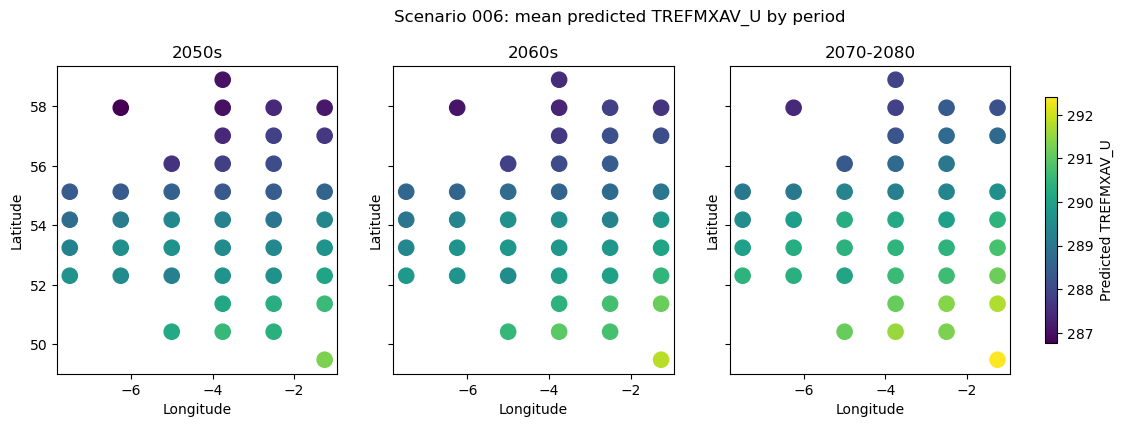

In [18]:
periods = ["2050s", "2060s", "2070-2080"]

vmin = spatial_period["pred_TREFMXAV_U"].min()
vmax = spatial_period["pred_TREFMXAV_U"].max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, period in zip(axes, periods):
    dfp = spatial_period[spatial_period["period"]==period]

    sc = ax.scatter(
        dfp["lon_plot"],
        dfp["lat"],
        c=dfp["pred_TREFMXAV_U"],
        s=120,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(period)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.colorbar(sc, ax=axes, label="Predicted TREFMXAV_U", shrink=0.8, pad=0.03)

fig.suptitle("Scenario 006: mean predicted TREFMXAV_U by period", y=1.02)
plt.show()

In [19]:
# Plot on a gridded field for a nicer plot

period_grids = {}

for period in periods:
    dfp = spatial_period[spatial_period["period"] == period]
    grid = dfp.pivot(index="lat", columns="lon_plot", values="pred_TREFMXAV_U")
    grid = grid.sort_index().sort_index(axis=1)
    period_grids[period] = grid

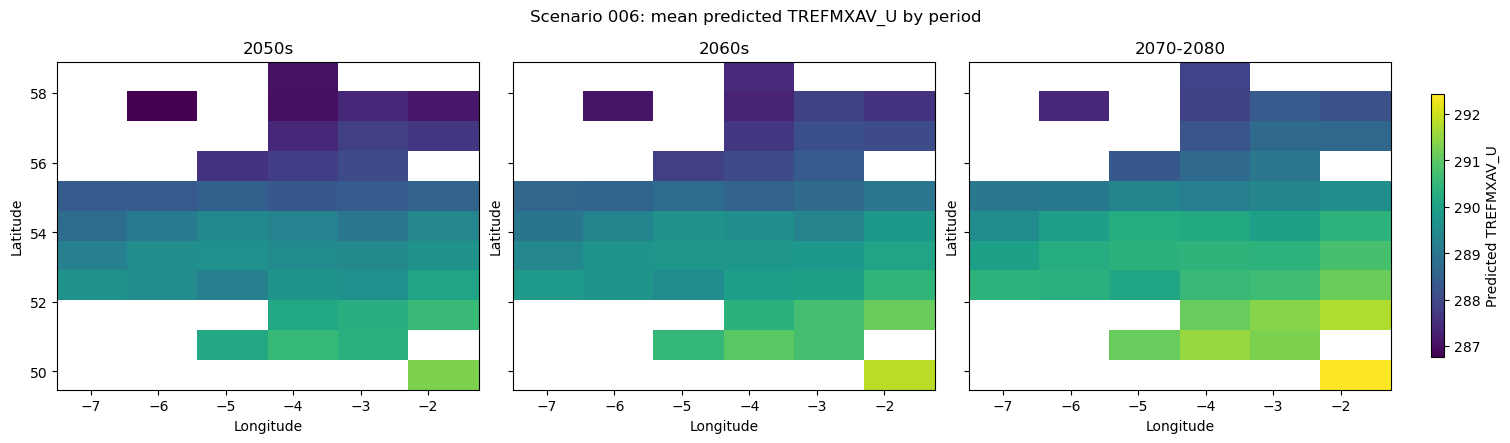

In [20]:
vmin = min(grid.min().min() for grid in period_grids.values())
vmax = max(grid.max().max() for grid in period_grids.values())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True, constrained_layout=True)

for ax, period in zip(axes, periods):
    grid = period_grids[period]

    im = ax.imshow(
        grid.values,
        origin="lower",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
    )

    ax.set_title(period)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.colorbar(im, ax=axes, label="Predicted TREFMXAV_U", shrink=0.8, pad=0.03)

fig.suptitle("Scenario 006: mean predicted TREFMXAV_U by period", y=1.07)
plt.show()

In [21]:
# Change maps relative to 2050 baseline - also correct the lon values

baseline = spatial_period[spatial_period["period"] == "2050s"][["lat", "lon_plot", "pred_TREFMXAV_U"]].rename(
    columns={"pred_TREFMXAV_U": "baseline_pred"}
)

spatial_change = spatial_period.merge(baseline, on=["lat", "lon_plot"], how="left")
spatial_change["change_from_2050s"] = spatial_change["pred_TREFMXAV_U"] - spatial_change["baseline_pred"]

spatial_change.head()

,period,lat,lon_plot,pred_TREFMXAV_U,baseline_pred,change_from_2050s
0,2050s,49.476440,-1.25,291.299100,291.299100,0.0
1,2050s,50.418850,-5.00,290.176994,290.176994,0.0
2,2050s,50.418850,-3.75,290.564240,290.564240,0.0
3,2050s,50.418850,-2.50,290.354851,290.354851,0.0
4,2050s,51.361256,-3.75,290.126829,290.126829,0.0


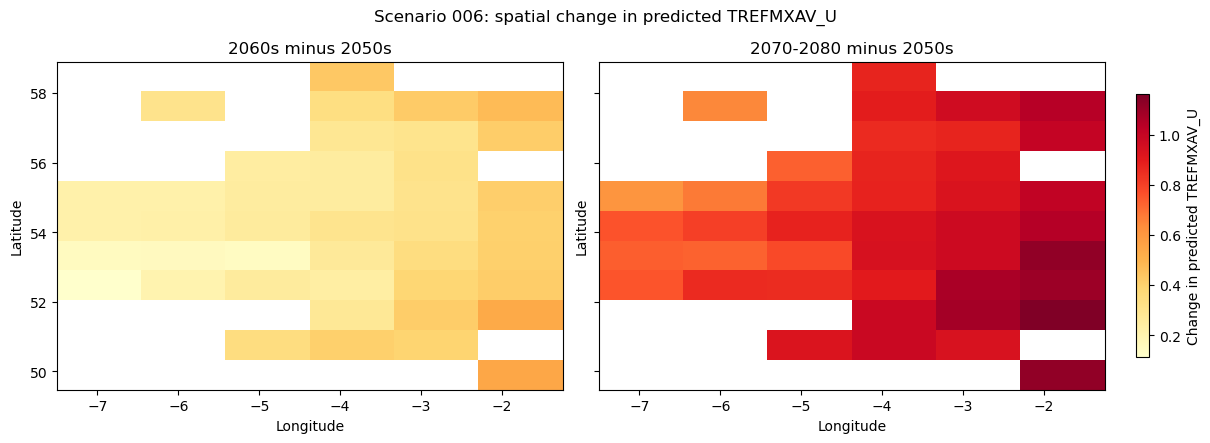

In [23]:
change_periods = ["2060s", "2070-2080"]

change_grids = {}

for period in change_periods:
    dfp = spatial_change[spatial_change["period"] == period]
    grid = dfp.pivot(index="lat", columns="lon_plot", values="change_from_2050s")
    grid = grid.sort_index().sort_index(axis=1)
    change_grids[period] = grid

all_change_vals = np.concatenate([grid.values.flatten() for grid in change_grids.values()])
all_change_vals = all_change_vals[~np.isnan(all_change_vals)]

vmin = all_change_vals.min()
vmax = all_change_vals.max()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True, constrained_layout=True)

for ax, period in zip(axes, change_periods):
    grid = change_grids[period]

    im = ax.imshow(
        grid.values,
        origin="lower",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        cmap="YlOrRd",
        extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
    )

    ax.set_title(f"{period} minus 2050s")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.colorbar(im, ax=axes, label="Change in predicted TREFMXAV_U", shrink=0.8, pad=0.03)

fig.suptitle("Scenario 006: spatial change in predicted TREFMXAV_U", y=1.07)
plt.show()

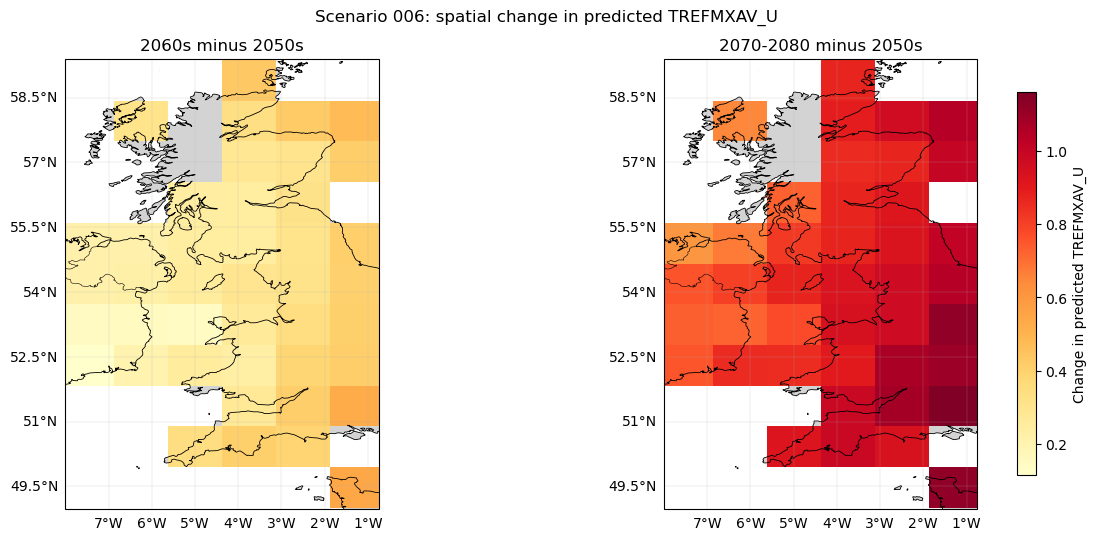

In [25]:
# Cartopy version with background map

change_periods = ["2060s", "2070-2080"]
change_grids = {}

for period in change_periods:
    dfp = spatial_change[spatial_change["period"] == period]
    grid = dfp.pivot(index="lat", columns="lon_plot", values="change_from_2050s")
    grid = grid.sort_index().sort_index(axis=1)
    change_grids[period] = grid

# Actual color scale from the data
all_change_vals = np.concatenate([grid.values.flatten() for grid in change_grids.values()])
all_change_vals = all_change_vals[~np.isnan(all_change_vals)]

vmin = all_change_vals.min()
vmax = all_change_vals.max()

# Map extent
all_lons = np.concatenate([grid.columns.values for grid in change_grids.values()])
all_lats = np.concatenate([grid.index.values for grid in change_grids.values()])

lon_min, lon_max = all_lons.min(), all_lons.max()
lat_min, lat_max = all_lats.min(), all_lats.max()

lon_buffer = 0.5
lat_buffer = 0.5

extent = [
    lon_min - lon_buffer,
    lon_max + lon_buffer,
    lat_min - lat_buffer,
    lat_max + lat_buffer,
]

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

for ax, period in zip(axes, change_periods):
    grid = change_grids[period]

    im = ax.pcolormesh(
        grid.columns.values,
        grid.index.values,
        grid.values,
        transform=ccrs.PlateCarree(),
        cmap="YlOrRd",
        vmin=vmin,
        vmax=vmax,
        shading="auto"
    )

    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(f"{period} minus 2050s")

cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.85, pad=0.03)
cbar.set_label("Change in predicted TREFMXAV_U")

fig.suptitle("Scenario 006: spatial change in predicted TREFMXAV_U", y=1.05, x=0.58)
fig.savefig(
    FIGURES_DIR / "scenario006_spatial_change_cartopy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()